PREPARATION + 2 LAYERS OF PROTOCOL + CHSH (42 - 56)
==

In [1]:
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit.visualization import plot_gate_map, plot_error_map

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator

from qiskit.transpiler import PassManager
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler.passes import TrivialLayout, FullAncillaAllocation, EnlargeWithAncilla, ApplyLayout
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
%matplotlib inline
import numpy as np 


from qiskit import transpile

In [2]:
service = QiskitRuntimeService(
    channel="", 
    token=""
)
real_backend = service.backend("")
noisy_sim = AerSimulator.from_backend(real_backend)
sim = AerSimulator()


target = real_backend.target

qiskit_runtime_service._discover_account:WARNING:2026-03-29 00:26:51,256: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-29 00:26:55,481: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-29 00:26:55,484: Using instance: open-instance, plan: open


In [3]:
print(f"Connected to: {real_backend.name}")
print(f"Number of qubits: {real_backend.num_qubits}")
print(f"Status: {real_backend.status().status_msg}")

Connected to: ibm_torino
Number of qubits: 133
Status: active


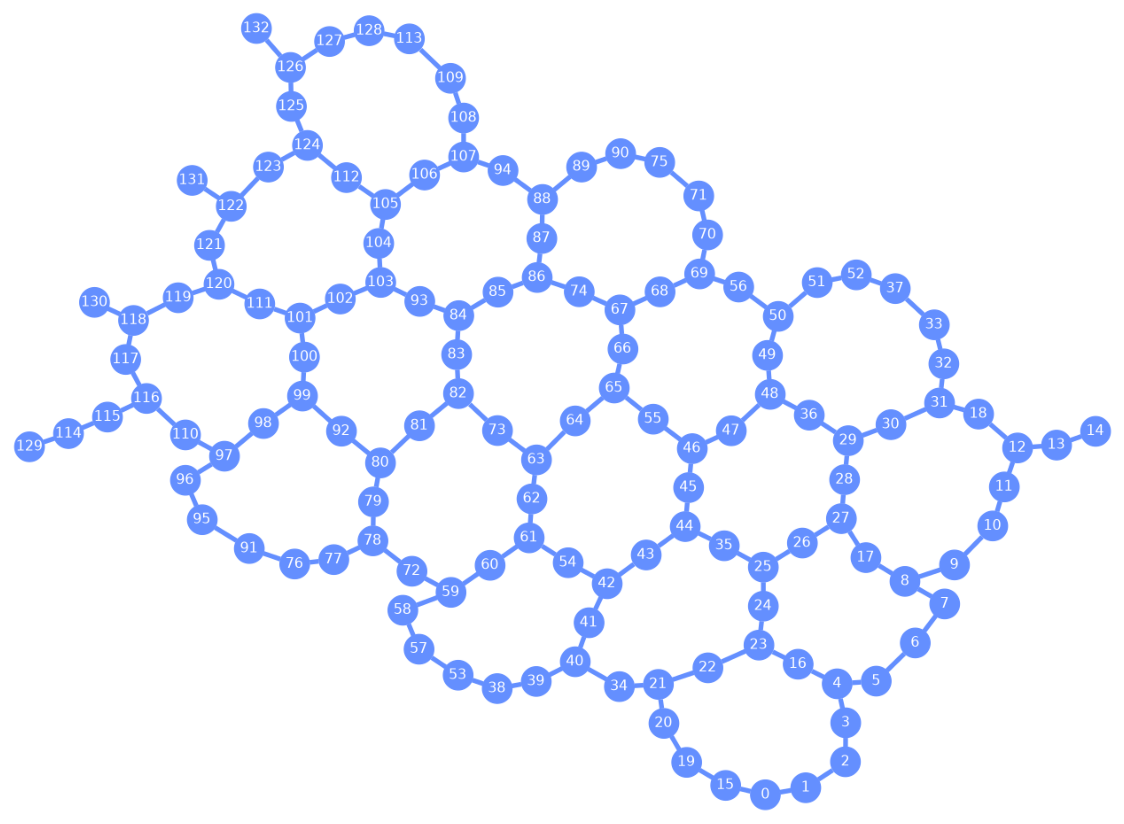

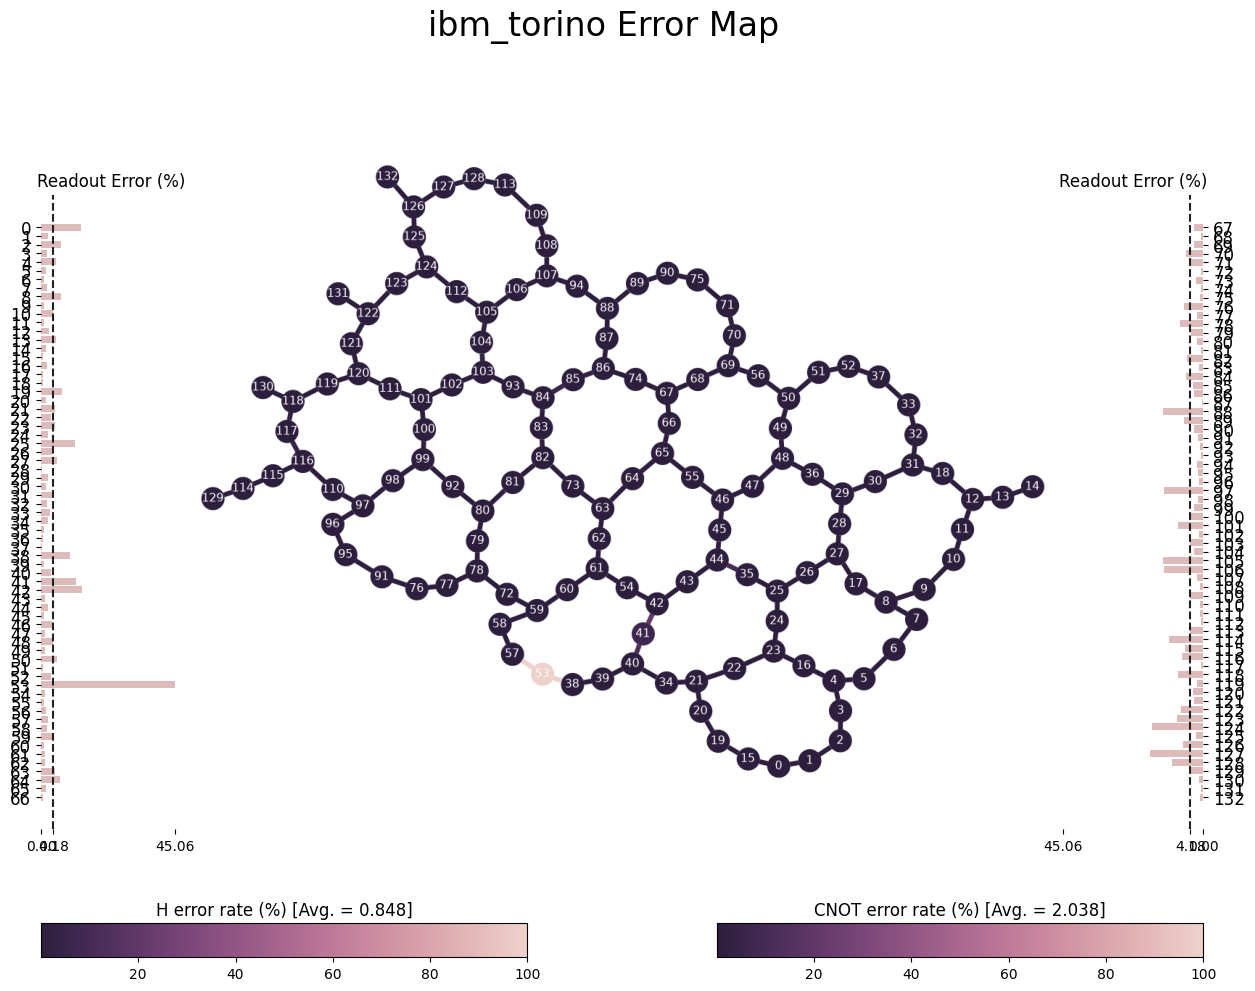

In [4]:
# Plot the physical connections (Topology)
plot_gate_map(real_backend)
plt.show()

# Plot a heat map of the gate errors across the whole chip
plot_error_map(real_backend)
plt.show()

Create a circuit

In [14]:
q = QuantumRegister(42)
c_out = ClassicalRegister(2)
c_ps = ClassicalRegister(6)

qc = QuantumCircuit(q, c_out, c_ps)
angle_h = np.pi*1/(2)



5 loops, 5 lists, from most bottom one - anti-clockwise
starting from bottom left loop then middle, right and top left 

In [15]:
l1 = [59,60,61,62,63,73,82,81,80,79,78,72]
l2 = [42,43,44,45,46,55,65,64,63,62,61,54]
l3 = [25,26,27,28,29,36,48,47,46,45,44,35]
l4 = [63,64,65,66,67,74,86,85,84,83,82,73]
l5 = [46,47,48,49,50,56,69,68,67,66,65,55]

lists = [l1, l2, l3, l4, l5]

initial_layout = []
seen = set()

for lst in lists:
    for x in lst:
        if x not in seen:
            initial_layout.append(x)
            seen.add(x)

print(initial_layout)

[59, 60, 61, 62, 63, 73, 82, 81, 80, 79, 78, 72, 42, 43, 44, 45, 46, 55, 65, 64, 54, 25, 26, 27, 28, 29, 36, 48, 47, 35, 66, 67, 74, 86, 85, 84, 83, 49, 50, 56, 69, 68]


In [16]:
pm = generate_preset_pass_manager(
    backend=real_backend, 
    optimization_level=3, #there are some different levels of optim.
    initial_layout=initial_layout
)

In [17]:
transpiled_qc = pm.run(qc)


define functions

In [18]:



def protocol(q0, q1, q2, q3):
    qc.x(q1)
    qc.cx(q0, q1)
    qc.h(q0)

    qc.x(q3)
    qc.cx(q2, q3)
    qc.h(q2)
    
    
def measurement_ps(q1, q3, c0, c1):
    qc.measure(q1, c0)
    qc.measure(q3, c1)
    
def chsh (qc, q0, q1, c0, c1):

    settings = [
        ("A0B0", False, -np.pi/4),
        ("A0B1", False, -3*np.pi/4),
        ("A1B0", True, -np.pi/4),
        ("A1B1", True, -3*np.pi/4)
    ]
    results_E=[]

    for label, apply_h, ry_angle in settings:
        qc2= qc.copy()
        if apply_h:
            qc2.h(q0)


        qc2.ry(ry_angle, q1)
        qc2.measure(q0, c0)
        qc2.measure(q1, c1)
        
        transpiled_qc = pm.run(qc2)

        

        sim = AerSimulator(method="matrix_product_state") #methods of aersim
        noisy_sim = AerSimulator.from_backend(real_backend)

        job = sim.run(qc2, shots=10000)
        #job = noisy_sim.run(qc2, shots=10000) 
        #job = noisy_sim.run(transpiled_qc, shots=10000)



        result = job.result()
        counts = result.get_counts()

        s00 = counts.get('000000 00', 0)
        s11 = counts.get('000000 11', 0)
        e01 = counts.get('000000 01', 0)
        e10 = counts.get('000000 10', 0)

        total = s00 + s11 + e01 + e10
        print(s00, s11, e01, e10)

        E = (s00 + s11 - e01 - e10) / total if total > 0 else 0
        results_E.append(E)

        print(f"Setting {label} | E = {E:.4f}")
        print(total)

        if len(results_E)==4:
            S = results_E[0] - results_E[1] + results_E[2] + results_E[3]
            print("\n" + "="*30)
            print(f"CHSH S-value: {S:.4f}")
            print("Violation?" , "YES" if abs(S) > 2 else "NO")
            print("="*30)




Preparation

Original Circuit:


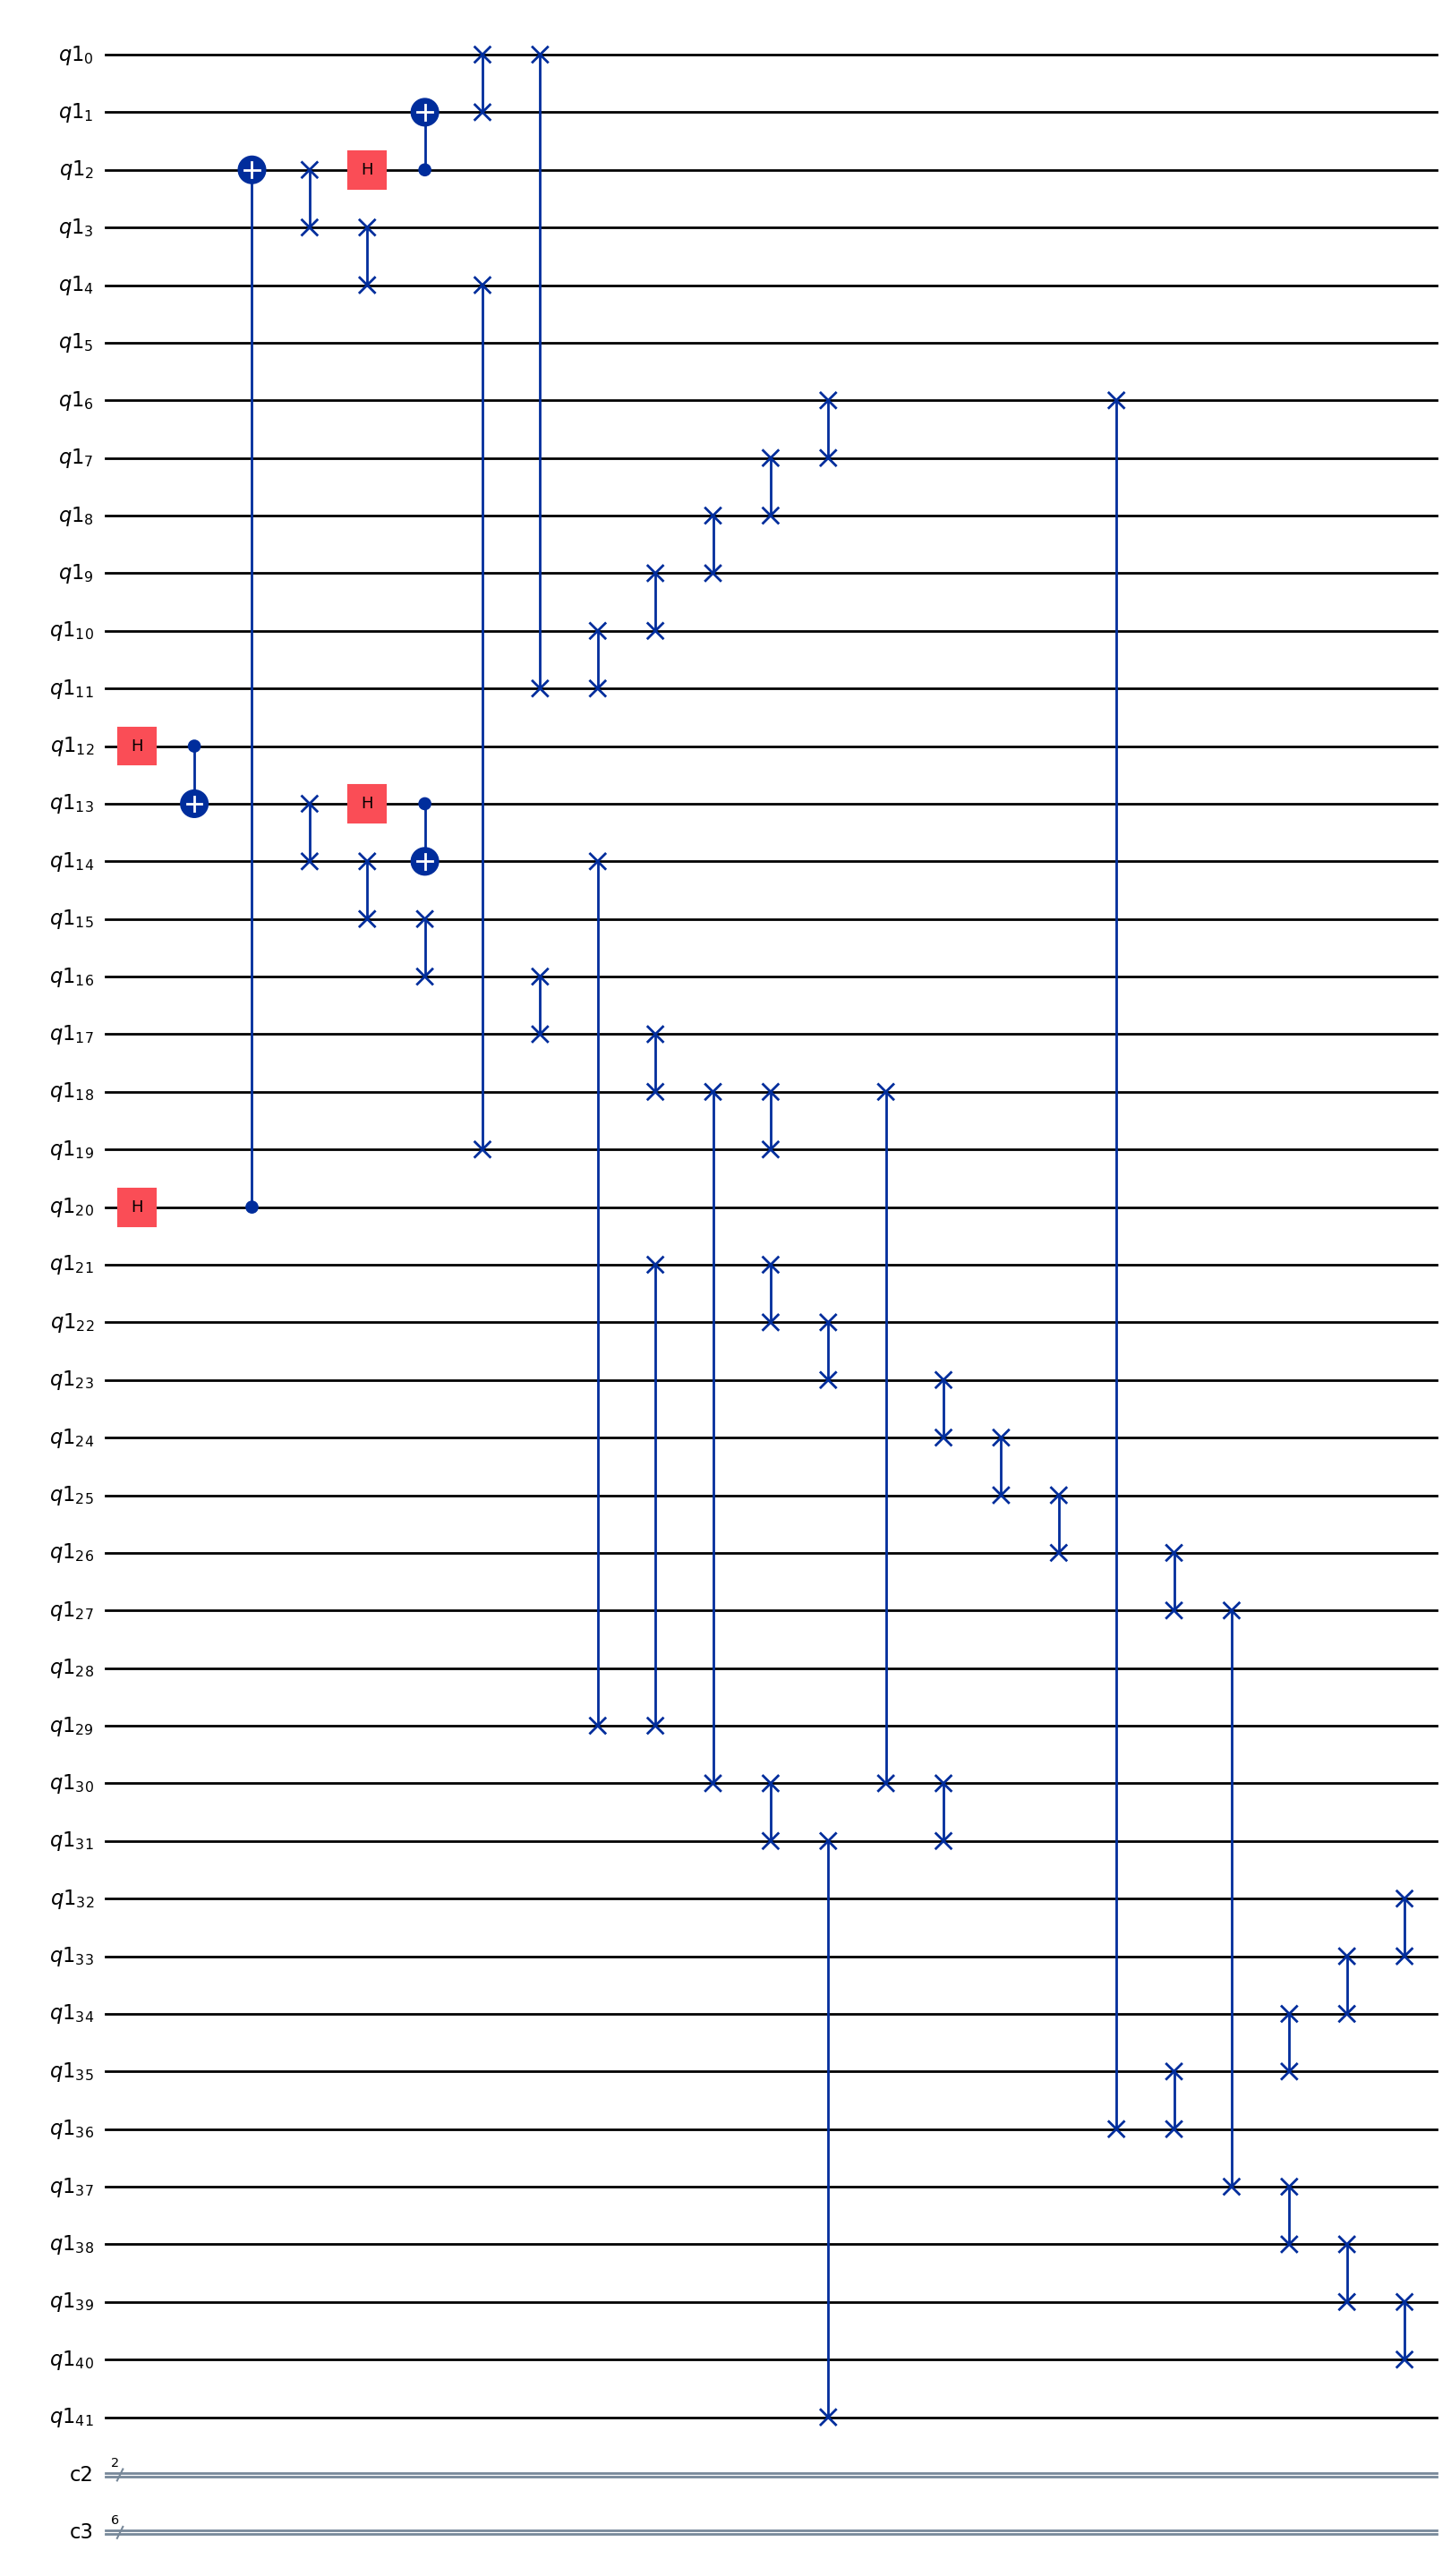

In [19]:
#normal order is 3,1,2,4





#3B - 3A
qc.h(12)
qc.cx(12,13)
qc.swap(13,14)
qc.swap(14,15)
qc.swap(15,16)
qc.swap(16,17)
qc.swap(17,18)
qc.swap(18,30)
qc.swap(30,31)
qc.swap(31,41)

#1B - 1A
qc.h(20)
qc.cx(20,2)
qc.swap(2,3)
qc.swap(3,4)
qc.swap(4,19)
qc.swap(19,18)
qc.swap(18,30)
qc.swap(30,31)

#2B - 2A
qc.h(2)
qc.cx(2,1)
qc.swap(1,0)
qc.swap(0,11)
qc.swap(11,10)
qc.swap(10,9)
qc.swap(9,8)
qc.swap(8,7)
qc.swap(7,6)
qc.swap(6,36)
qc.swap(36,35)
qc.swap(35,34)
qc.swap(34,33)
qc.swap(33,32)

#4B - 4A
qc.h(13)
qc.cx(13,14)
qc.swap(14,29)
qc.swap(29,21)
qc.swap(21,22)
qc.swap(22,23)
qc.swap(23,24)
qc.swap(24,25)
qc.swap(25,26)
qc.swap(26,27)
qc.swap(27,37)
qc.swap(37,38)
qc.swap(38,39)
qc.swap(39,40)





print("Original Circuit:")
qc.draw('mpl')
plt.show()

In [20]:
#call functions


protocol(q[2], q[20], q[32], q[31])
protocol(q[12], q[13], q[41], q[40])
protocol(q[20], q[12], q[31], q[41])

measurement_ps(q[2], q[32], c_ps[0], c_ps[1])
measurement_ps(q[12], q[41], c_ps[2], c_ps[3])
measurement_ps(q[13], q[40], c_ps[4], c_ps[5])

In [21]:
print(qc.num_qubits)
print(qc.depth())

42
23


In [23]:
chsh(qc, q[31], q[20], c_out[0], c_out[1])


530 545 78 118
Setting A0B0 | E = 0.6916
1271
81 95 528 512
Setting A0B1 | E = -0.7105
1216
560 508 81 89
Setting A1B0 | E = 0.7254
1238
565 494 86 87
Setting A1B1 | E = 0.7192
1232

CHSH S-value: 2.8466
Violation? YES


In [ ]:
2.8576